In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import sys

# Tell Python where your custom folder lives in Drive
folder_path = '/content/drive/MyDrive/Contrastive_Learning_Cifar-10'
if folder_path not in sys.path:
    sys.path.append(folder_path)

In [4]:
!pip install -q torch torchvision tqdm scikit-learn matplotlib

## 1. Import the modules
From here on, this notebook only calls functions defined in the `.py` files above.


In [5]:
import data, model, loss, train, evaluate, experiments
import torch, json
import matplotlib.pyplot as plt
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Modules imported OK. Device:', DEVICE)

Modules imported OK. Device: cuda


## 2. Config

In [6]:
DATASET = 'cifar10'          
SUBSET_SIZE = 5000         #convenience default for fast iteration,
BATCH_SIZE = 256
EPOCHS = 10
TEMPERATURE = 0.5
EMBEDDING_DIM = 128
PROJECTION_DIM = 64
IN_CHANNELS = 1 if DATASET == 'mnist' else 3

## 3. Dataset sanity check
Calls `data.get_dataloaders` and visualizes a positive pair (two augmented views of the same image).

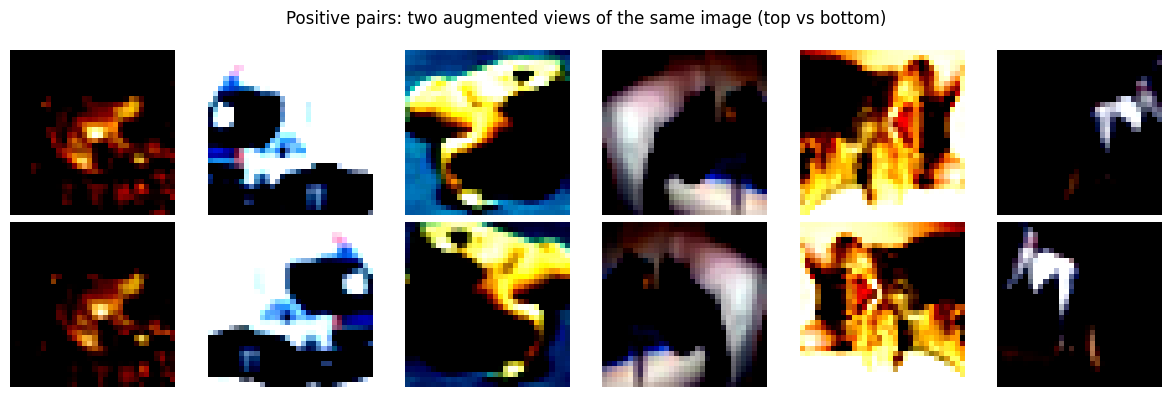

In [7]:
_probe_loader, _, _ = data.get_dataloaders(dataset=DATASET, strength='weak', batch_size=8, subset_size=200)
x1, x2, y = next(iter(_probe_loader))

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    img1 = x1[i].permute(1, 2, 0).numpy() if IN_CHANNELS == 3 else x1[i, 0].numpy()
    img2 = x2[i].permute(1, 2, 0).numpy() if IN_CHANNELS == 3 else x2[i, 0].numpy()
    axes[0, i].imshow(img1, cmap='gray' if IN_CHANNELS == 1 else None); axes[0, i].axis('off')
    axes[1, i].imshow(img2, cmap='gray' if IN_CHANNELS == 1 else None); axes[1, i].axis('off')
fig.suptitle('Positive pairs: two augmented views of the same image (top vs bottom)')
plt.tight_layout(); plt.show()

## 4. Baseline — evaluate BEFORE training
Calls `model.ContrastiveModel`, and `evaluate.extract_embeddings` / `.knn_accuracy` / `.similarity_gap` / `.retrieval_recall_at_k` / `.collapse_diagnostics` / `.plot_embeddings_2d`.


{
  "knn_accuracy": 0.3003,
  "similarity_gap": {
    "S_same": 0.9987711906433105,
    "S_diff": 0.9985542893409729,
    "gap": 0.00021690130233764648
  },
  "recall@5": 0.6521,
  "collapse": {
    "mean_per_dim_variance": 1.1334077498759143e-05,
    "avg_pairwise_cosine_similarity": 0.9986278414726257,
    "likely_collapsed": true
  }
}


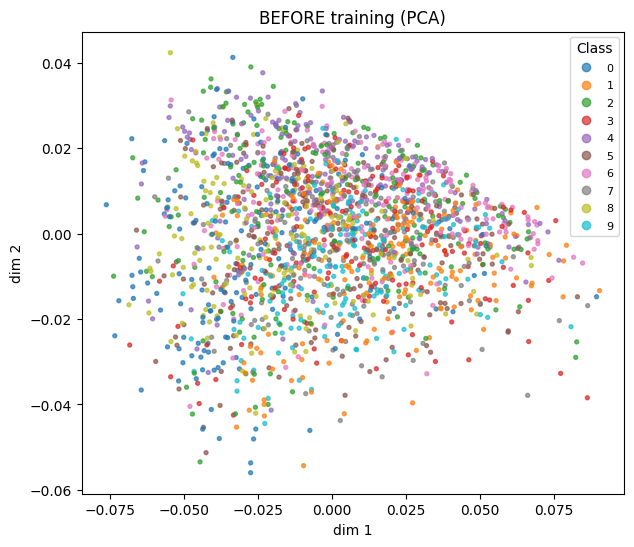

In [8]:
contrastive_loader, eval_train_loader, eval_test_loader = data.get_dataloaders(
    dataset=DATASET, strength='weak', batch_size=BATCH_SIZE, subset_size=SUBSET_SIZE)

net = model.ContrastiveModel(in_channels=IN_CHANNELS, embedding_dim=EMBEDDING_DIM,
                              projection_dim=PROJECTION_DIM, use_projection_head=True)
net = net.to(DEVICE)

train_emb0, train_labels0 = evaluate.extract_embeddings(net, eval_train_loader, device=DEVICE)
test_emb0, test_labels0 = evaluate.extract_embeddings(net, eval_test_loader, device=DEVICE)

before = {
    'knn_accuracy': evaluate.knn_accuracy(train_emb0, train_labels0, test_emb0, test_labels0, k=10),
    'similarity_gap': evaluate.similarity_gap(test_emb0, test_labels0),
    'recall@5': evaluate.retrieval_recall_at_k(test_emb0, test_labels0, train_emb0, train_labels0, k=5),
    'collapse': evaluate.collapse_diagnostics(test_emb0),
}
print(json.dumps(before, indent=2))
evaluate.plot_embeddings_2d(test_emb0, test_labels0, method='pca', title='BEFORE training (PCA)')

## 5. Train
Calls `train.train_contrastive`.



In [9]:
history = train.train_contrastive(net, contrastive_loader, epochs=EPOCHS, temperature=TEMPERATURE, device=DEVICE)


Epoch 1/10: 100%|██████████| 19/19 [00:09<00:00,  2.04it/s, gap=0.931, loss=4.79]


[Epoch 1] loss=5.1614 pos_sim=0.9429 neg_sim=0.2386 gap=0.7043


Epoch 2/10: 100%|██████████| 19/19 [00:06<00:00,  2.72it/s, gap=0.968, loss=4.6] 


[Epoch 2] loss=4.6888 pos_sim=0.9607 neg_sim=0.0073 gap=0.9534


Epoch 3/10: 100%|██████████| 19/19 [00:08<00:00,  2.15it/s, gap=0.96, loss=4.52] 


...

[Epoch 8] loss=4.4252 pos_sim=0.9693 neg_sim=0.0019 gap=0.9673


Epoch 9/10: 100%|██████████| 19/19 [00:08<00:00,  2.16it/s, gap=0.967, loss=4.42]


[Epoch 9] loss=4.4155 pos_sim=0.9702 neg_sim=0.0010 gap=0.9693


Epoch 10/10: 100%|██████████| 19/19 [00:07<00:00,  2.59it/s, gap=0.967, loss=4.42]

[Epoch 10] loss=4.4097 pos_sim=0.9721 neg_sim=0.0024 gap=0.9697


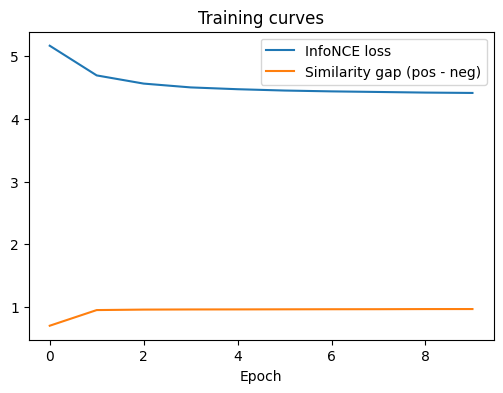

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(history['epoch_loss'], label='InfoNCE loss')
plt.plot(history['epoch_gap'], label='Similarity gap (pos - neg)')
plt.xlabel('Epoch'); plt.legend(); plt.title('Training curves')
plt.show()

## 6. Evaluate AFTER training, and compare

{
  "knn_accuracy": 0.3088,
  "similarity_gap": {
    "S_same": 0.4404405653476715,
    "S_diff": 0.3520071804523468,
    "gap": 0.08843338489532471
  },
  "recall@5": 0.6499,
  "collapse": {
    "mean_per_dim_variance": 0.004991940688341856,
    "avg_pairwise_cosine_similarity": 0.36358532309532166,
    "likely_collapsed": false
  }
}


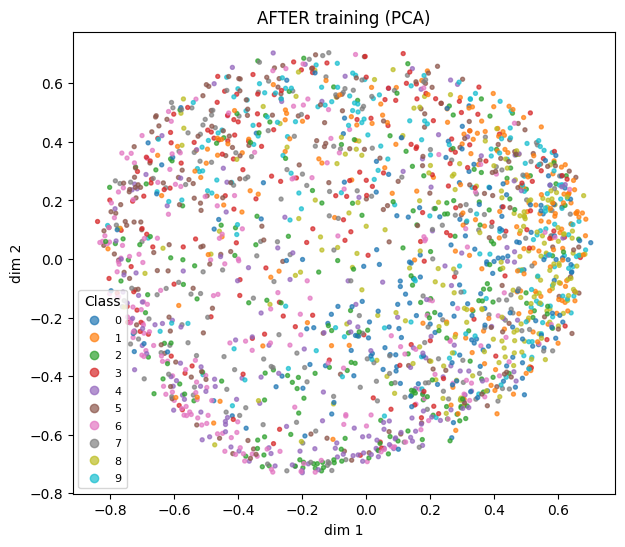

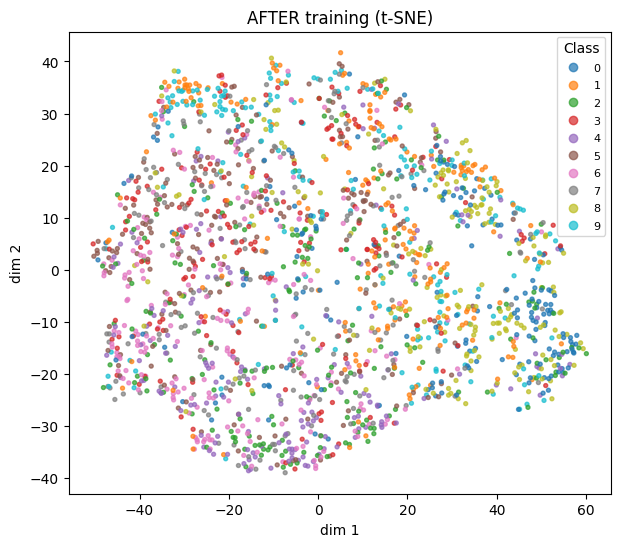


==== BEFORE vs AFTER ====
k-NN accuracy:  0.3003  ->  0.3088
Similarity gap: 0.0002  ->  0.0884
Recall@5:       0.6521  ->  0.6499
Collapsed?      True  ->  False


In [11]:
train_emb1, train_labels1 = evaluate.extract_embeddings(net, eval_train_loader, device=DEVICE)
test_emb1, test_labels1 = evaluate.extract_embeddings(net, eval_test_loader, device=DEVICE)

after = {
    'knn_accuracy': evaluate.knn_accuracy(train_emb1, train_labels1, test_emb1, test_labels1, k=10),
    'similarity_gap': evaluate.similarity_gap(test_emb1, test_labels1),
    'recall@5': evaluate.retrieval_recall_at_k(test_emb1, test_labels1, train_emb1, train_labels1, k=5),
    'collapse': evaluate.collapse_diagnostics(test_emb1),
}
print(json.dumps(after, indent=2))

evaluate.plot_embeddings_2d(test_emb1, test_labels1, method='pca', title='AFTER training (PCA)',
                             )
evaluate.plot_embeddings_2d(test_emb1, test_labels1, method='tsne', title='AFTER training (t-SNE)',
                             )

print('\n==== BEFORE vs AFTER ====')
print(f"k-NN accuracy:  {before['knn_accuracy']:.4f}  ->  {after['knn_accuracy']:.4f}")
print(f"Similarity gap: {before['similarity_gap']['gap']:.4f}  ->  {after['similarity_gap']['gap']:.4f}")
print(f"Recall@5:       {before['recall@5']:.4f}  ->  {after['recall@5']:.4f}")
print(f"Collapsed?      {before['collapse']['likely_collapsed']}  ->  {after['collapse']['likely_collapsed']}")


## 7. Retrieval demo
Shows real query images and their top-5 nearest neighbors in the trained embedding space, using `data.load_base_dataset`.

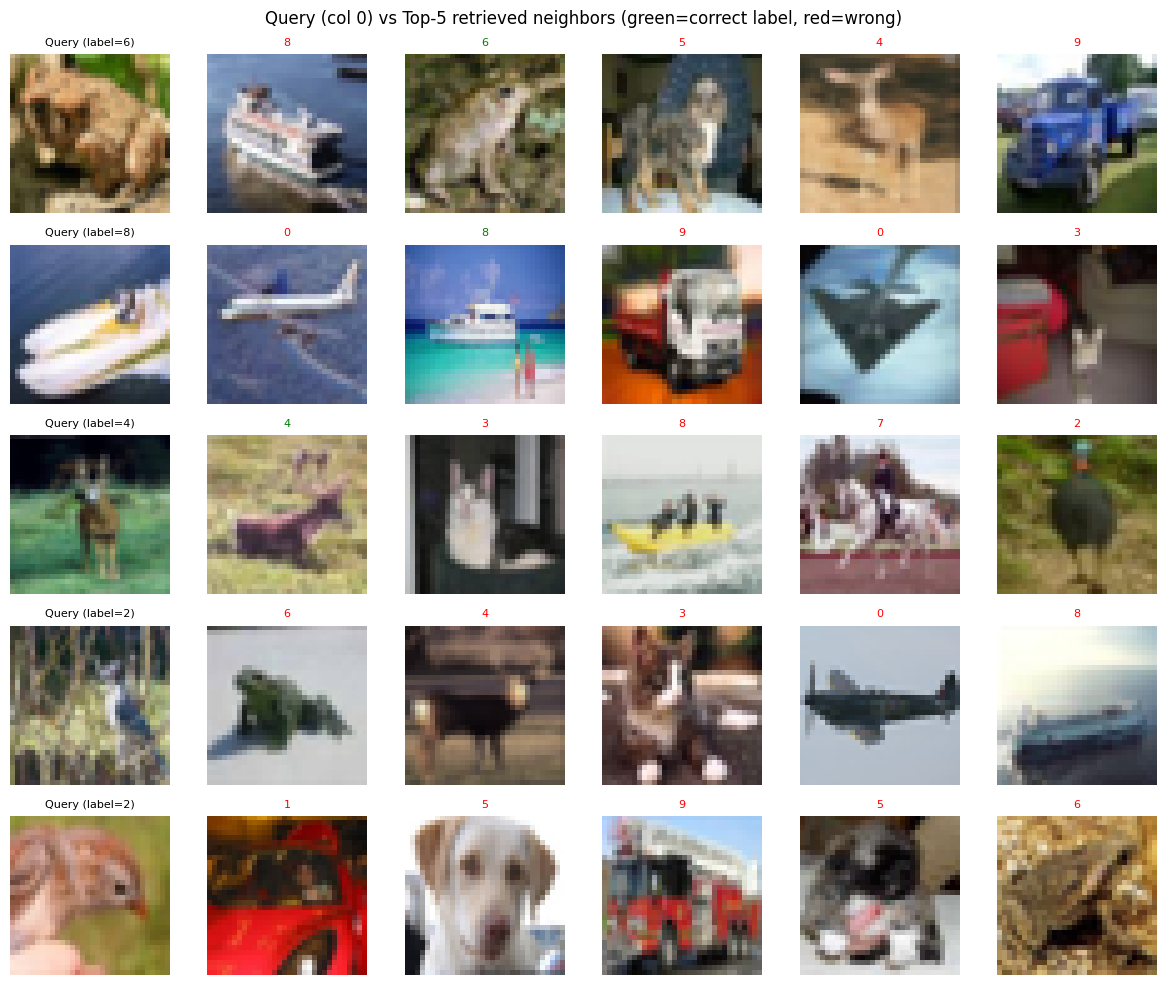

In [12]:
raw_test = data.load_base_dataset(DATASET, train=False)
base_train_for_display = data.load_base_dataset(DATASET, train=True)

n_queries = 5
query_indices = np.random.default_rng(1).choice(len(test_emb1), size=n_queries, replace=False)

fig, axes = plt.subplots(n_queries, 6, figsize=(12, 2 * n_queries))
for row, qi in enumerate(query_indices):
    sims = test_emb1[qi:qi+1] @ train_emb1.T
    top5 = sims[0].argsort()[::-1][:5]

    q_img, q_label = raw_test[qi]
    axes[row, 0].imshow(q_img, cmap='gray' if IN_CHANNELS == 1 else None)
    axes[row, 0].set_title(f'Query (label={q_label})', fontsize=8)
    axes[row, 0].axis('off')

    for col, ti in enumerate(top5):
        img, label = base_train_for_display[ti]
        axes[row, col + 1].imshow(img, cmap='gray' if IN_CHANNELS == 1 else None)
        correct = (label == q_label)
        axes[row, col + 1].set_title(f'{label}', fontsize=8, color='green' if correct else 'red')
        axes[row, col + 1].axis('off')

plt.suptitle('Query (col 0) vs Top-5 retrieved neighbors (green=correct label, red=wrong)')
plt.tight_layout(); plt.show()

## 8. Controlled Experiments
Calls `experiments.experiment_temperature`, `.experiment_augmentation`, `.experiment_projection_head` directly — defined in `experiments.py`, not duplicated here.


=== Experiment 1: Temperature ===

=== Experiment 1: temperature=0.05 ===


Epoch 1/10: 100%|██████████| 19/19 [00:06<00:00,  2.74it/s, gap=0.852, loss=0.996]


[Epoch 1] loss=2.2565 pos_sim=0.9615 neg_sim=0.3542 gap=0.6074


Epoch 2/10: 100%|██████████| 19/19 [00:09<00:00,  2.06it/s, gap=0.918, loss=0.431]


[Epoch 2] loss=0.5885 pos_sim=0.9461 neg_sim=0.0355 gap=0.9106


...

[Epoch 8] loss=0.0555 pos_sim=0.9325 neg_sim=0.0081 gap=0.9245


Epoch 9/10: 100%|██████████| 19/19 [00:06<00:00,  2.76it/s, gap=0.925, loss=0.0358]


[Epoch 9] loss=0.0473 pos_sim=0.9352 neg_sim=0.0099 gap=0.9253


Epoch 10/10: 100%|██████████| 19/19 [00:09<00:00,  2.05it/s, gap=0.927, loss=0.0272]

[Epoch 10] loss=0.0427 pos_sim=0.9326 neg_sim=0.0095 gap=0.9231


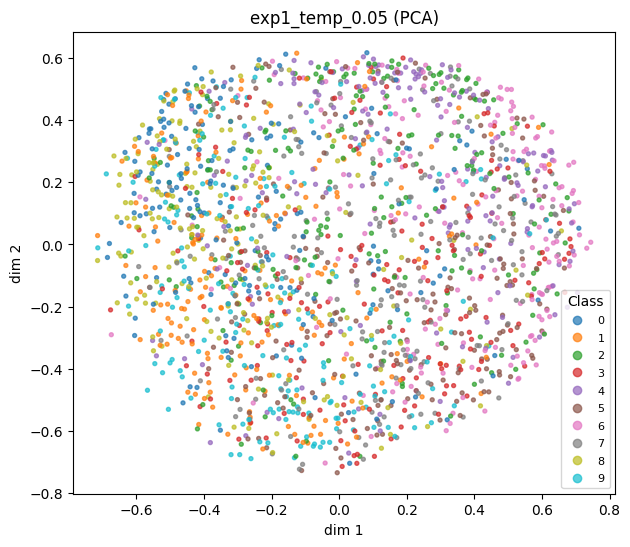


=== Experiment 1: temperature=0.5 ===


Epoch 1/10: 100%|██████████| 19/19 [00:08<00:00,  2.18it/s, gap=0.936, loss=4.74]


[Epoch 1] loss=5.0851 pos_sim=0.9465 neg_sim=0.2181 gap=0.7284


Epoch 2/10: 100%|██████████| 19/19 [00:07<00:00,  2.55it/s, gap=0.96, loss=4.6]  


[Epoch 2] loss=4.6584 pos_sim=0.9584 neg_sim=0.0062 gap=0.9522


...

[Epoch 8] loss=4.4226 pos_sim=0.9701 neg_sim=0.0034 gap=0.9667


Epoch 9/10: 100%|██████████| 19/19 [00:08<00:00,  2.35it/s, gap=0.968, loss=4.41]


[Epoch 9] loss=4.4142 pos_sim=0.9712 neg_sim=0.0035 gap=0.9677


Epoch 10/10: 100%|██████████| 19/19 [00:08<00:00,  2.22it/s, gap=0.972, loss=4.4] 

[Epoch 10] loss=4.4062 pos_sim=0.9720 neg_sim=0.0025 gap=0.9694


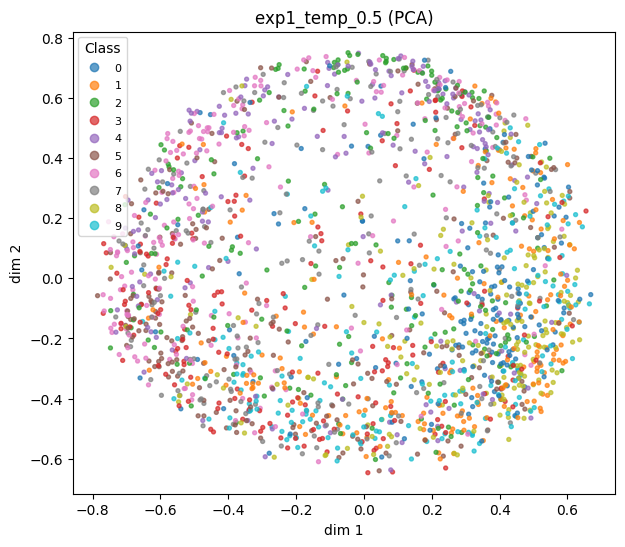


=== Experiment 1: temperature=1.0 ===


Epoch 1/10: 100%|██████████| 19/19 [00:09<00:00,  2.06it/s, gap=0.95, loss=5.42] 


[Epoch 1] loss=5.6204 pos_sim=0.9486 neg_sim=0.2372 gap=0.7114


Epoch 2/10: 100%|██████████| 19/19 [00:07<00:00,  2.71it/s, gap=0.974, loss=5.37]


[Epoch 2] loss=5.3921 pos_sim=0.9659 neg_sim=0.0043 gap=0.9616


...

[Epoch 8] loss=5.3017 pos_sim=0.9781 neg_sim=0.0003 gap=0.9778


Epoch 9/10: 100%|██████████| 19/19 [00:09<00:00,  2.05it/s, gap=0.978, loss=5.3] 


[Epoch 9] loss=5.2993 pos_sim=0.9785 neg_sim=0.0010 gap=0.9774


Epoch 10/10: 100%|██████████| 19/19 [00:06<00:00,  2.76it/s, gap=0.976, loss=5.3] 

[Epoch 10] loss=5.2976 pos_sim=0.9789 neg_sim=0.0022 gap=0.9767


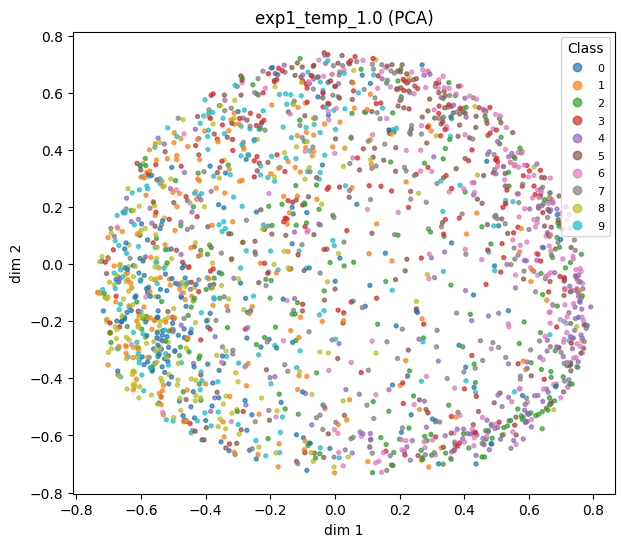

In [13]:
print('=== Experiment 1: Temperature ===')
exp1_results = experiments.experiment_temperature(dataset=DATASET, subset_size=SUBSET_SIZE, epochs=EPOCHS)


=== Experiment 2: Augmentation strength ===

=== Experiment 2: augmentation=weak ===


Epoch 1/10: 100%|██████████| 19/19 [00:08<00:00,  2.31it/s, gap=0.949, loss=4.75]


[Epoch 1] loss=5.1351 pos_sim=0.9494 neg_sim=0.2352 gap=0.7143


Epoch 2/10: 100%|██████████| 19/19 [00:07<00:00,  2.38it/s, gap=0.959, loss=4.61]


[Epoch 2] loss=4.6691 pos_sim=0.9561 neg_sim=0.0065 gap=0.9496


...

[Epoch 8] loss=4.4233 pos_sim=0.9688 neg_sim=0.0033 gap=0.9655


Epoch 9/10: 100%|██████████| 19/19 [00:09<00:00,  2.08it/s, gap=0.966, loss=4.42]


[Epoch 9] loss=4.4116 pos_sim=0.9704 neg_sim=0.0018 gap=0.9685


Epoch 10/10: 100%|██████████| 19/19 [00:06<00:00,  2.72it/s, gap=0.967, loss=4.41]

[Epoch 10] loss=4.4076 pos_sim=0.9709 neg_sim=0.0024 gap=0.9685


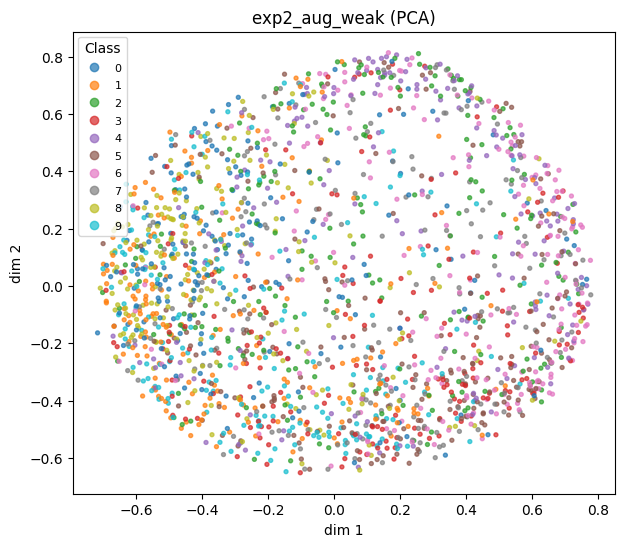


=== Experiment 2: augmentation=strong ===


Epoch 1/10: 100%|██████████| 19/19 [00:16<00:00,  1.17it/s, gap=0.476, loss=5.68]


[Epoch 1] loss=5.8578 pos_sim=0.7074 neg_sim=0.3937 gap=0.3137


Epoch 2/10: 100%|██████████| 19/19 [00:16<00:00,  1.16it/s, gap=0.528, loss=5.57]


[Epoch 2] loss=5.6100 pos_sim=0.5910 neg_sim=0.0645 gap=0.5265


...

[Epoch 8] loss=5.2149 pos_sim=0.6613 neg_sim=0.0061 gap=0.6552


Epoch 9/10: 100%|██████████| 19/19 [00:16<00:00,  1.18it/s, gap=0.663, loss=5.19]


[Epoch 9] loss=5.1846 pos_sim=0.6703 neg_sim=0.0032 gap=0.6671


Epoch 10/10: 100%|██████████| 19/19 [00:16<00:00,  1.18it/s, gap=0.698, loss=5.12]

[Epoch 10] loss=5.1893 pos_sim=0.6677 neg_sim=0.0049 gap=0.6628


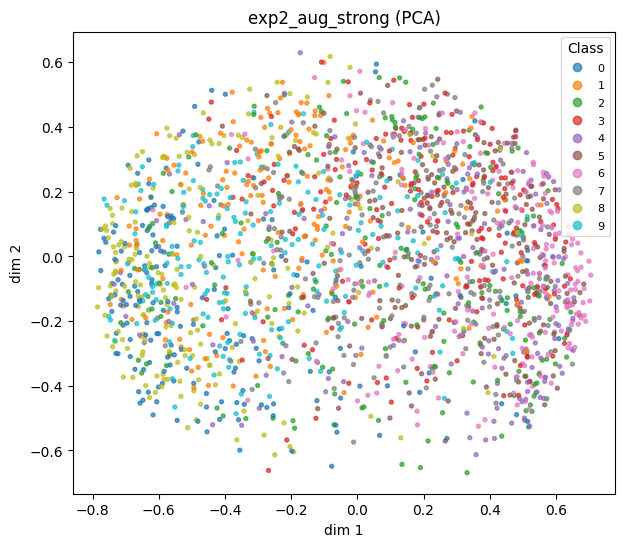

In [15]:
print('=== Experiment 2: Augmentation strength ===')
exp2_results = experiments.experiment_augmentation(dataset=DATASET, subset_size=SUBSET_SIZE, epochs=EPOCHS, temperature=TEMPERATURE)


=== Experiment 3: Projection head ===

=== Experiment 3: use_projection_head=True ===


Epoch 1/10: 100%|██████████| 19/19 [00:06<00:00,  2.73it/s, gap=0.932, loss=4.81]


[Epoch 1] loss=5.1734 pos_sim=0.9368 neg_sim=0.2280 gap=0.7088


Epoch 2/10: 100%|██████████| 19/19 [00:09<00:00,  2.04it/s, gap=0.958, loss=4.6] 


[Epoch 2] loss=4.6988 pos_sim=0.9492 neg_sim=0.0067 gap=0.9425


...

[Epoch 8] loss=4.4301 pos_sim=0.9694 neg_sim=0.0020 gap=0.9674


Epoch 9/10: 100%|██████████| 19/19 [00:07<00:00,  2.66it/s, gap=0.968, loss=4.42]


[Epoch 9] loss=4.4201 pos_sim=0.9699 neg_sim=0.0009 gap=0.9690


Epoch 10/10: 100%|██████████| 19/19 [00:09<00:00,  2.10it/s, gap=0.967, loss=4.42]

[Epoch 10] loss=4.4127 pos_sim=0.9714 neg_sim=0.0020 gap=0.9694


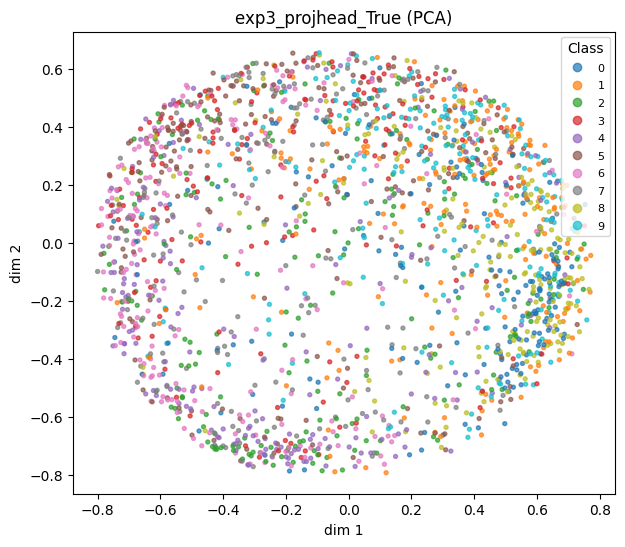


=== Experiment 3: use_projection_head=False ===


Epoch 1/10: 100%|██████████| 19/19 [00:08<00:00,  2.30it/s, gap=0.932, loss=4.75]


[Epoch 1] loss=5.0974 pos_sim=0.9563 neg_sim=0.2407 gap=0.7156


Epoch 2/10: 100%|██████████| 19/19 [00:07<00:00,  2.43it/s, gap=0.961, loss=4.63]


[Epoch 2] loss=4.6730 pos_sim=0.9624 neg_sim=0.0072 gap=0.9552


...

[Epoch 8] loss=4.4288 pos_sim=0.9679 neg_sim=-0.0019 gap=0.9697


Epoch 9/10: 100%|██████████| 19/19 [00:07<00:00,  2.64it/s, gap=0.968, loss=4.41]


[Epoch 9] loss=4.4172 pos_sim=0.9681 neg_sim=-0.0017 gap=0.9698


Epoch 10/10: 100%|██████████| 19/19 [00:09<00:00,  2.07it/s, gap=0.972, loss=4.4] 

[Epoch 10] loss=4.4060 pos_sim=0.9695 neg_sim=-0.0020 gap=0.9715


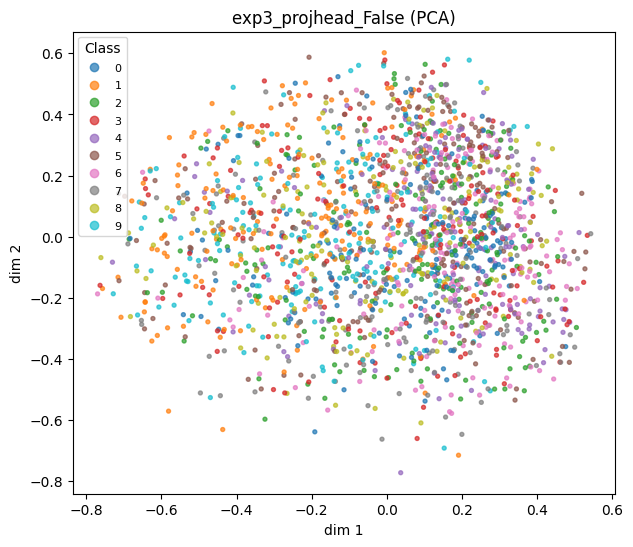

In [16]:
print('=== Experiment 3: Projection head ===')
exp3_results = experiments.experiment_projection_head(dataset=DATASET, subset_size=SUBSET_SIZE, epochs=EPOCHS, temperature=TEMPERATURE)


## 9. Combined summary + save results

In [17]:
all_results = {**exp1_results, **exp2_results, **exp3_results}


print('==== FULL SUMMARY TABLE ====')
for name, r in all_results.items():
    print(f"{name:22s} | loss={r['final_train_loss']:.3f} | knn_acc={r['knn_accuracy']:.3f} | "
          f"gap={r['test_similarity_gap']['gap']:.3f} | recall@5={r['retrieval_recall@5']:.3f} | "
          f"collapsed={r['collapse_diagnostics']['likely_collapsed']}")

==== FULL SUMMARY TABLE ====
exp1_temp_0.05         | loss=0.043 | knn_acc=0.351 | gap=0.078 | recall@5=0.689 | collapsed=False
exp1_temp_0.5          | loss=4.406 | knn_acc=0.294 | gap=0.088 | recall@5=0.642 | collapsed=False
exp1_temp_1.0          | loss=5.298 | knn_acc=0.285 | gap=0.114 | recall@5=0.637 | collapsed=False
exp2_aug_weak          | loss=4.408 | knn_acc=0.299 | gap=0.093 | recall@5=0.640 | collapsed=False
exp2_aug_strong        | loss=5.189 | knn_acc=0.385 | gap=0.119 | recall@5=0.716 | collapsed=False
exp3_projhead_True     | loss=4.413 | knn_acc=0.302 | gap=0.111 | recall@5=0.645 | collapsed=False
exp3_projhead_False    | loss=4.406 | knn_acc=0.325 | gap=0.054 | recall@5=0.669 | collapsed=False
